<a href="https://colab.research.google.com/github/MarjanaPrifti/introtoai/blob/main/workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center> **Workshop for ACM Summer School 2026**

This workshop is in two parts, the first is a follow-along notebook and then we have a more open-ended
task for you to mess around with. Any doubts whatsoever, please raise your hand and we'll come over and help, but we'll also do our best to walk around.

Before starting, please run the following cell to install QiliSDK and ensure it runs:

In [ ]:
%pip install qilisdk==0.2.1 > /dev/null
import qilisdk
print(f"QiliSDK installed with version {qilisdk.__version__}")

QiliSDK installed with version 0.2.1


# Digital

So, you saw a bit about digital quantum computing in the slides, but what does that look like in QiliSDK?

First let's start by making a simple 3-qubit circuit:

In [ ]:
from qilisdk.digital import Circuit

c = Circuit(nqubits=3)

Now we need to add some gates. Let's start with a single X gate, which flips the qubit (qubit 0, since we start from 0 because we aren't heretics), from the state 0 to the state 1:

In [ ]:
from qilisdk.digital import X
c.add(X(0))

If we now draw this:

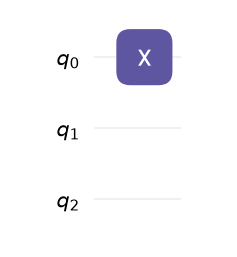

In [ ]:
c.draw()

Here you can see that we have three lines, each representing a different qubit. The X gate acts on the first one, so we should change from being in state 000 to state 100. To see this, we need to simulate the circuit.

To do so, first we need to construct our backend (our quantum simulator), our functional (the task we want to perform) and our readout (the type of results we want to get). In this case we want to propagate our circuit and take samples of it at the end:

In [ ]:
from qilisdk.backends import QiliSim
from qilisdk.functionals import DigitalPropagation
from qilisdk.readout import Readout

backend = QiliSim()
functional = DigitalPropagation(c)
readout = Readout().with_sampling(nshots=1000)

If we now run our simulation:

In [ ]:
results = backend.execute(functional, readout)
print(results)

- Functional Results: [

Sampling Results: (
	nshots=1000,
	samples={'100': 1000}
)

]


Here you can see that we get 1000 samples of the "100" state, exactly as we expected!

But what about something more "quantum"? Because right now this is very "classical", after all we just did a single NOT on a bitstring, that's not very fancy at all.

Let's instead create something called a "GHZ" state. To do this, we first need to use a Hadamard gate to put the circuit into quantum superposition, then use CNOTs to tell each qubit that they should flip their state if the state of the above qubit is 1, and do nothing otherwise:

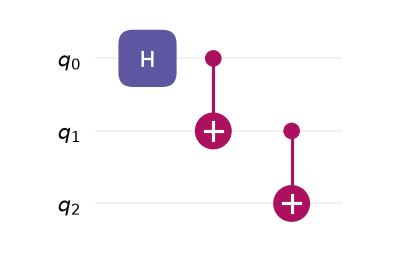

In [ ]:
from qilisdk.digital import H, CNOT
c = Circuit(nqubits=3)
c.add(H(0))
c.add(CNOT(0, 1))
c.add(CNOT(1, 2))
c.draw()

Before you run it, try to guess what you think the result is going to be!

In [ ]:
functional = DigitalPropagation(c)
results = backend.execute(functional, readout)
print(results)

- Functional Results: [

Sampling Results: (
	nshots=1000,
	samples={'000': 478, '111': 522}
)

]


Here you see that the output is split 50/50 between being in the 000 state and the 111 state.

Since the Hadamard created a superposition, the first qubit was both 0 and 1 at the same time. The CNOTs then copied this superposition to the other qubits. Then, when we measured at the end, the superposition collapsed, either to 000 or to 111.

This is also an example of quantum entanglement, where the state of one qubit depends on the state of another.

# Analog

Now that we've seen how to build and simulate a digital circuit with QiliSDK, we'll now look at doing the same for analog annealing jobs.

Analog quantum computing is different from digital in that digital uses a Circuit filled with Gates, so we start from the zero state and keep applying gates and then measure the output at the end. In analog quantum computing, we evolve a Hamiltonian, basicilly a special quantum object which describes the energy of the system.

To build a simple Hamiltonian in QiliSDK looks like this:

In [ ]:
from qilisdk.analog import X, Y, Z

hamiltonian = 3 * X(0) + 2 * Z(1) * Z(2)
print(hamiltonian)

3 X(0) + 2 Z(1) Z(2)


This builds a very simple Hamiltonian made from two Pauli operators, X and Z. In this case we have a term of 3 times the Pauli X operator acting on qubit 0, then 2 times the product of Pauli Z acting on qubits 1 and 2.

You can kind of think of these like the gates from before, except now rather than doing these once (in a digital/discrete type of way) we're going to perform a continuous evolution of these.

Mathematically, we would apply the evolution:

$$ U = e^{iH\Delta t} $$

where $H$ is our Hamiltonian, $U$ is the operator we are going to apply to the state and $\Delta t$ is the change in time we want to simulate. So then what we want to compute at the end of our simulation (or on a real quantum computer) is something like:

$$ |\psi_{i+1}\rangle = U |\psi_i\rangle $$

where $|\psi_i\rangle$ and $|\psi_{i+1}\rangle$ are our initial and next quantum states, respectively. By doing smaller $\Delta t$ we can improve the accuracy and stability of the evolution.

# Quantum Annealing

So, maths out of the way, what does that actually *mean*? How can we actually use this?

One of the main practical uses for evolving a Hamiltonian like this is something known as Quantum Annealing.

Some of you may be familiar with Simulated Annealing, which is the classical version. In that, you try to find the solution to an optimization problem by randomizing the solution, accepting small changes based on some temperature, then slowly decreasing the temperature until the system isn't making any changes at all, and hopefully has reached the true optimum of your problem. There are some guarantees that as long as you decrease the temperature slowly enough, you're guaranteed to find the minimum of your problem.

Quantum Annealing is similar in the sense that we want to transition slowly in order to find the optimum, and we have similar theoretical guarantees.

Alright, let's get back to the code. First we need an optimization problem to solve, for that we're going to use the QiliSDK model class to generate a random Ising problem:

In [ ]:
from qilisdk.core import Model
nqubits = 3
model = Model.random_ising(nqubits)
print(model)

Model name: Random Ising 
objective (obj): 
	 minimize : 
	 (0.023643249400513433) * x0 + (0.9009273926518706) * (x0 * x1) + (-0.7116807745607325) * (x0 * x2) + (0.8972988942744877) * x1 + (-0.3763370959790291) * (x1 * x2) + (-0.1533471020548487) * x2 




This has created a randomized Ising problem, basicially a set of binary variables x0, x1 and x2, such that we want to minimize some randomized weighted sum of them. This isn't that useful a problem in this case, but trust me when I say almost any problem can be put into this format (for those that know complexity classes, the decision version of the generalized Ising model is NP-Complete).

This is still in a very general form, we want to convert it to a Hamiltonian (to be explained why later):

In [ ]:
final_hamiltonian = model.to_qubo().to_hamiltonian()
print(final_hamiltonian)

0.3370249013381035 - 0.059133279223041235 Z(0) - 0.5797970213054543 Z(1) + 0.22523184816296765 Z(0) Z(1) + 0.34867801866236475 Z(2) - 0.17792019364018313 Z(0) Z(2) - 0.09408427399475727 Z(1) Z(2)


As the asute among you might already be guessing, since we called this final_hamiltonian it means were going to transition from a different Hamiltonian to this one. Quantum annealing works by transitioning from a Hamiltonian where you know the solution\* to one that we don't (our problem Hamiltonian).

\* When I say we know the "solution" of a Hamiltonian, I mean the ground state, the lowest energy state, the eigenvector with the lowest eigenvalue if we convert the Hamiltonian to a matrix.

The easy starting Hamiltonian we are going to use is the standard one, the negative sum of all Xs, for which it's known that the ground state is a uniform superposition (applying a Hadamard to every qubit), something that tends to be relatively easy to prepare in the hardware and is also easy to simulate.

To create this starting Hamiltonian in QiliSDK, as before:

In [ ]:
starting_hamiltonian = -sum([X(i) for i in range(nqubits)])
print(starting_hamiltonian)

- X(0) - X(1) - X(2)


We then need to define our Schedule, the way that we want to interpolate between these two hamiltonians:

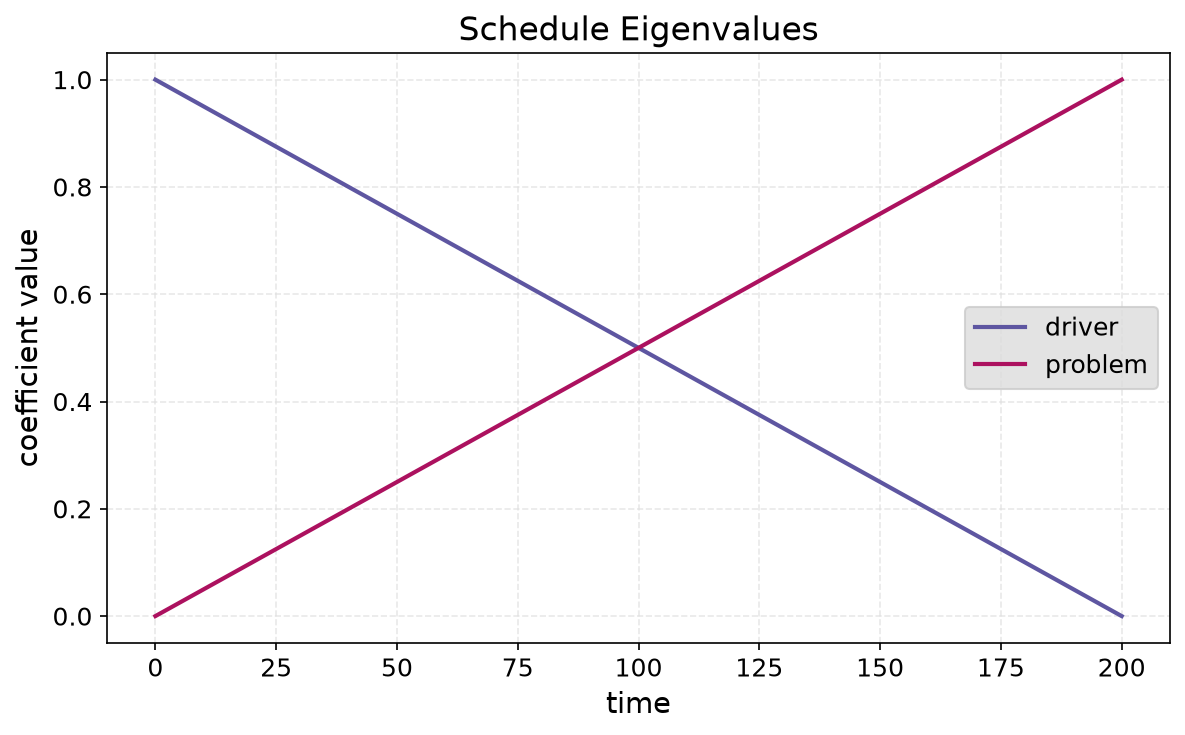

In [ ]:
from qilisdk.analog import Schedule
T = 200.0
dt = 0.1
schedule = Schedule.linear(starting_hamiltonian, final_hamiltonian, T, dt)
schedule.draw()

Here you can see that our coefficient for our driver (i.e. initial) Hamiltonian linearly goes from 1.0 to 0.0 after a time of T, whilst our problem Hamiltonian does the opposite and goes from 0.0 to 1.0. So hopefully you can see how we plan to transition from one Hamiltonian to the other. A longer T is gonna mean a slower evolution, whilst the dt that we set is just about how granular we want our simulation to be (smaller means more accurate but slower).

Now, as we did before for the digital, we need to set up our backend, our task and our readout. In this case we want to readout the expectation value (solution value) rather than just sampling from our final state.

In [ ]:
from qilisdk.backends import QiliSim
from qilisdk.functionals import AnalogEvolution
from qilisdk.readout import Readout
from qilisdk.core import InitialState

backend = QiliSim()
functional = AnalogEvolution(schedule, initial_state=InitialState.UNIFORM, store_intermediate_results=True)
readout = Readout().with_expectation([final_hamiltonian]).with_state_tomography()

Now we run the simulation:

In [ ]:
results = backend.execute(functional, readout)

Every Hamiltonian has an eigenspectra (the set of different energy levels). Since we want to start in the lowest and stay in the lowest, let's view whether we did that (note, this might take 30 seconds or so, it has to compute a lot of stuff):

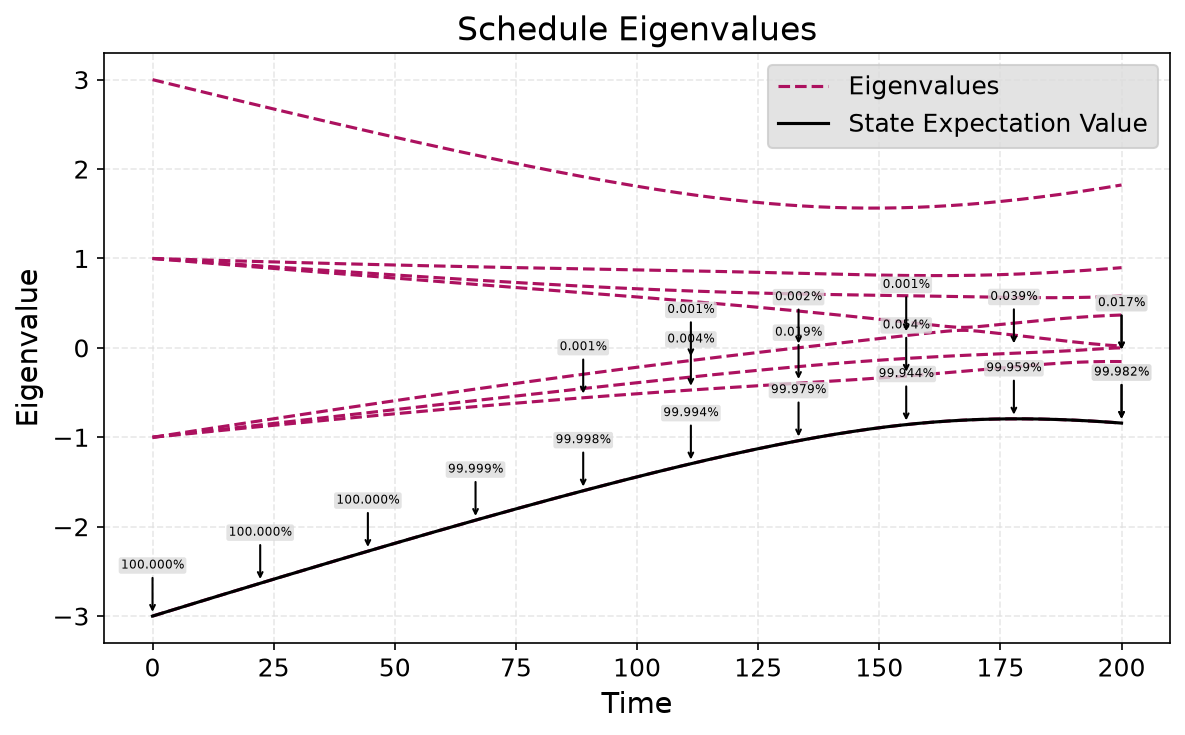

In [ ]:
schedule.draw_eigenvalues(intermediate_states=results.get_intermediate_states(), show_overlaps=True)

The above graph shows that we (the black line) started in the lowest energy level and finished in the lowest level, with only a small fraction of our state leaking out into the higher levels.

Now let's get the actual expectation value itself:



In [ ]:
print(results.get_expectation_values()[0])

-0.841251122912845


So, we have a value, but how do we know if it's right? Well we can compare to a brute force solve of the original problem:

In [ ]:
from qilisdk.utils.classical_solvers import BruteForceSolver
true_solution = BruteForceSolver().solve(model)
print(true_solution)

({'obj': -0.8413846272150678}, {x0: 1, x1: 0, x2: 1})


As you can see, we get pretty close! We can get much closer by increasing the time that we anneal and maybe decreasing the dt for a more accurate simulation.

# Your Turn!

Your task now is to use quantum annealing to solve the following Knapsack problem using quantum annealing:

> Imagine you're a tourist coming to Barcelona. You have a backpack which has a weight limit of 3 kg. You want to pack as many souveneirs from your trip to Barcelona as you can, to try to maximize the value:
>
> - An "I Heart Barcelona" T-shirt, 100 g, 1 eur
>  - A 6-pack of Estrella Damm, 2 kg, 6 eur
>  - A bottle of Ratafia, 700 g, 13 eur
>  - A water pistol, 300g 2 eur
>  - Barça jersey, 100g 20 eur

 To do this, the QiliSDK documentation might be helpful: https://qilimanjaro-tech.github.io/qilisdk/en/0.2.1/modules/core/core_model.html#constructors


# Extensions

If you manage to get a result for the above problem, try the following:

 - How close can you get to the optimal solution? Explore what happens if you tweak the lagrange multiplier, total time and dt.
 - Try to solve this problem as a quantum circuit using a technique known as Trotterization. See https://qilimanjaro-tech.github.io/qilisdk/en/0.2.1/modules/digital/digital_trotter.html
 - Another way to solve this problem digitally is to use a technique called QAOA. See https://qilimanjaro-tech.github.io/qilisdk/en/0.2.1/modules/digital/digital_qaoa.html